In [1]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer

## Part 1: Features Setup/Further Refining of Data

In [2]:
final_df = pd.read_csv('./data/finalCards.csv')
# color 'U' is Blue, 'B' is Black

final_df.columns

Index(['uuid', 'cardName', 'availability', 'colorIdentity', 'defense',
       'edhrecRank', 'edhrecSaltiness', 'finishes', 'isAlternative',
       'isGameChanger', 'isPromo', 'isReprint', 'isReserved', 'keywords',
       'layout', 'loyalty', 'manaCost', 'manaValue', 'cardNumber', 'power',
       'rarity', 'setCode', 'subtypes', 'supertypes', 'text', 'toughness',
       'types', 'variations', 'price', 'commander', 'setName', 'releaseDate',
       'scryfallId', 'tcgplayerProductId', 'multiverseId', 'isHuman',
       'isElemental', 'isDragon', 'isSpirit', 'isAngel', 'isElf', 'isVampire',
       'isZombie', 'isBeast', 'isEldrazi', 'isWizard', 'isSoldier', 'isKnight',
       'isCleric', 'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isCreature',
       'isPlaneswalker', 'isMTGO', 'isLegal', 'isBanned', 'isBattle',
       'isFlying'],
      dtype='str')

In [ ]:
# replace categorical with numbers
# 0.5 are special cases
final_df.commander = final_df.commander.map({'NotLegal':0, 'Banned':0.5, 'Legal':1})
final_df.rarity = final_df.rarity.map({'common':0, 'special':0.5, 'uncommon':1, 'rare':2, 'mythic':3})
final_df = final_df.replace({True: 1, False: 0})

#so it doesn't split words into individual letters
final_df.colorIdentity = final_df.colorIdentity.str.replace(',', '')

In [4]:
boolean_features = ['isAlternative','isGameChanger','isPromo','isReprint',
                    'isReserved','isHuman','isElemental', 'isDragon', 
                    'isSpirit', 'isAngel', 'isElf', 'isVampire',
                    'isZombie', 'isBeast', 'isEldrazi', 'isWizard', 
                    'isSoldier', 'isKnight','isCleric', 'isWarrior', 
                    'isRogue', 'isShaman', 'isDruid', 'isCreature',
                    'isPlaneswalker', 'isMTGO', 'isLegal', 'isBanned', 
                    'isBattle']

final_df[boolean_features] = final_df[boolean_features].apply(pd.to_numeric, axis=1)
# , errors='coerce', 

In [5]:
noncreature_df = final_df.copy()
noncreature_df = noncreature_df[(noncreature_df['isCreature'] != 1)] #  & (noncreature_df['isReprint'] == 0)
noncreature_df = noncreature_df[[
       'uuid', 'cardName', 'availability', 'colorIdentity',
       'edhrecRank', 'edhrecSaltiness', 'finishes', 'isAlternative',
       'isGameChanger', 'isPromo', 'isReserved', 'keywords',
       'layout', 'loyalty', 'manaValue', 'cardNumber', 'isReprint',
       'rarity', 'setCode', 'subtypes', 'supertypes', 'text',
       'types', 'price', 'commander', 'setName', 'releaseDate',
       'isPlaneswalker', 'isBattle', 'isFlying', 'isEldrazi'
       ]]

print(len(noncreature_df))

49287


In [6]:
planeswalker_df = final_df[(final_df['isPlaneswalker'] == True)] # & (final_df['isReprint'] == 0)
planeswalker_df = planeswalker_df.drop(columns=['variations', 'defense', 
                                                'power', 'toughness',
                                                'isLegal', 'isBanned',  
                                                'isEldrazi', 'manaCost',
                                                'isPlaneswalker', 'isMTGO'])
planeswalker_df.head()

,uuid,cardName,availability,colorIdentity,edhrecRank,edhrecSaltiness,finishes,isAlternative,isGameChanger,isPromo,...,isSoldier,isKnight,isCleric,isWarrior,isRogue,isShaman,isDruid,isCreature,isBattle,isFlying
43,001e28fe-5bc1-57ef-9814-adc1195a297b,"Liliana, the Last Hope",paper,B,7063.0,0.26,foil,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
85,00396ed6-b91d-5c78-8760-bb22d8f3e9ca,"Tevesh Szat, Doom of Fools","mtgo, paper",B,3174.0,0.57,"nonfoil, foil",0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
87,003d9ecd-53bc-55c7-993f-26ec405f71e4,"Gideon, Martial Paragon","mtgo, paper",W,15747.0,0.37,foil,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
219,009c0efc-d03f-5a9d-8df9-d0fd2e94b4ca,"Liliana, Waker of the Dead",paper,B,5185.0,0.79,foil,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
281,00be1adb-2ca4-5485-ba27-94f0e96eb2d9,"Minsc & Boo, Timeless Heroes",paper,G R,3343.0,0.54,foil,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [7]:
print(len(planeswalker_df))
planeswalker_df.isna().sum()

1324


uuid                     0
cardName                 0
availability             0
colorIdentity            0
edhrecRank              15
edhrecSaltiness         47
finishes                 0
isAlternative            0
isGameChanger            0
isPromo                  0
isReprint                0
isReserved               0
keywords                 0
layout                   0
loyalty                 20
manaValue                0
cardNumber               0
rarity                   0
setCode                  0
subtypes                 0
supertypes               0
text                     0
types                    0
price                    0
commander                0
setName                  0
releaseDate              0
scryfallId               0
tcgplayerProductId      19
multiverseId           614
isHuman                 17
isElemental             17
isDragon                17
isSpirit                17
isAngel                 17
isElf                   17
isVampire               17
i

In [8]:
creature_df = final_df.copy()
creature_df = creature_df[(creature_df['isCreature'] == 1)] #  & (creature_df['isReprint'] == 0)
creature_df = creature_df[['availability', 'cardName', 'colorIdentity',
       'edhrecRank', 'edhrecSaltiness', 'finishes', 'isAlternative',
       'isGameChanger', 'isPromo', 'isReserved', 'keywords',
       'manaValue', 'power', 'rarity', 'subtypes', 'isReprint',
       'supertypes', 'toughness', 'types', 'price', 'commander', 'isHuman',
       'isElemental', 'isDragon', 'isSpirit', 'isAngel', 'isElf', 'isVampire',
       'isZombie', 'isBeast', 'isWizard', 'isSoldier', 'isKnight', 'isCleric',
       'isWarrior', 'isRogue', 'isShaman', 'isDruid', 'isCreature',
       'isPlaneswalker', 'isFlying', 'isBattle', 'isEldrazi']]

# text, cardName, scryfall ids
# colorless pips (diamond) vs. generics pips (circles w/numbers in them)

creature_df.isna().sum()

availability           0
cardName               0
colorIdentity          0
edhrecRank           627
edhrecSaltiness     6833
finishes               0
isAlternative          0
isGameChanger          0
isPromo                0
isReserved             0
keywords               0
manaValue              0
power                711
rarity                 0
subtypes               0
isReprint              0
supertypes             0
toughness            576
types                  0
price                  0
commander              0
isHuman                4
isElemental            4
isDragon               4
isSpirit               4
isAngel                4
isElf                  4
isVampire              4
isZombie               4
isBeast                4
isWizard               4
isSoldier              4
isKnight               4
isCleric               4
isWarrior              4
isRogue                4
isShaman               4
isDruid                4
isCreature             0
isPlaneswalker         0


In [ ]:
# A lot of cards that are really cheap
# but quite a few expensive ones too

def priceOutlier(df):
    df['Zscore'] = zscore(df['price'])

    no_outliers = df[df['Zscore'].abs() <= 3]
    no_outliers = no_outliers.drop(columns=['Zscore'])
    print(len(df), len(no_outliers))

    return no_outliers

In [10]:
noncreature_df = priceOutlier(noncreature_df)
noncreature_df['price'].sort_values(ascending=False)

49287 49190


59490    1540.355000
71830    1540.294000
51342    1522.516667
60377    1500.228000
885      1499.990000
            ...     
74074       0.095000
41696       0.090000
73087       0.030000
50670       0.030000
13008       0.020000
Name: price, Length: 49190, dtype: float64

In [11]:
planeswalker_df = priceOutlier(planeswalker_df)
planeswalker_df['price'].sort_values(ascending=False)

1324 1308


19504    155.6700
60577    152.2560
54737    134.0500
65110    132.1475
19403     92.3250
           ...   
85158      0.1975
26006      0.1820
26773      0.1820
57584      0.1780
88705      0.1600
Name: price, Length: 1308, dtype: float64

In [12]:
creature_df = priceOutlier(creature_df)
creature_df['price'].sort_values(ascending=False)

44836 44698


42088    369.745000
51810    369.440000
92798    364.281667
84971    360.890000
68518    350.714000
            ...    
831        0.090000
91830      0.082000
29011      0.030000
45825      0.030000
89391      0.020000
Name: price, Length: 44698, dtype: float64

In [13]:
# how do we handle cases like these that are clearly unique
# and have "special" subtypes?
#creature_df.subtypes = creature_df.subtypes.str.replace('Lady of Proper Etiquette', 'Lady-of-Proper-Etiquette')
#creature_df.subtypes = creature_df.subtypes.str.replace('The Biggest Baddest Nastiest', 'The-Biggest-Baddest-Nastiest')

#creature_df.subtypes = creature_df.subtypes.str.replace('and/or', ',')
#creature_df.subtypes = creature_df.subtypes.str.replace(',', '')

In [ ]:
# feature bloat

"""
creature_df.keywords = creature_df.keywords.str.replace('Partner with', 'Partner-with')
creature_df.keywords = creature_df.keywords.str.replace('Hexproof from', 'Hexproof-from')
creature_df.keywords = creature_df.keywords.str.replace('Max speed', 'Max-speed')
creature_df.keywords = creature_df.keywords.str.replace('Pack tactics', 'Pack-tactics')
creature_df.keywords = creature_df.keywords.str.replace('Start your engines!', 'Start-your-engines!')
creature_df.keywords = creature_df.keywords.str.replace('More Than Meets the Eye', 'More-Than-Meets-the-Eye')
creature_df.keywords = creature_df.keywords.str.replace('Will of the Council', 'Will-of-the-Council')
creature_df.keywords = creature_df.keywords.str.replace('Open an Attraction', 'Open-an-Attraction')
creature_df.keywords = creature_df.keywords.str.replace('Roll to Visit Your Attractions', 'Roll-to-Visit-Your-Attractions')
creature_df.keywords = creature_df.keywords.str.replace('Venture into the dungeon', 'Venture-into-the-dungeon')
creature_df.keywords = creature_df.keywords.str.replace('Choose a background', 'Choose-a-background')
"""

"\ncreature_df.keywords = creature_df.keywords.str.replace('Partner with', 'Partner-with')\ncreature_df.keywords = creature_df.keywords.str.replace('Hexproof from', 'Hexproof-from')\ncreature_df.keywords = creature_df.keywords.str.replace('Max speed', 'Max-speed')\ncreature_df.keywords = creature_df.keywords.str.replace('Pack tactics', 'Pack-tactics')\ncreature_df.keywords = creature_df.keywords.str.replace('Start your engines!', 'Start-your-engines!')\ncreature_df.keywords = creature_df.keywords.str.replace('More Than Meets the Eye', 'More-Than-Meets-the-Eye')\ncreature_df.keywords = creature_df.keywords.str.replace('Will of the Council', 'Will-of-the-Council')\ncreature_df.keywords = creature_df.keywords.str.replace('Open an Attraction', 'Open-an-Attraction')\ncreature_df.keywords = creature_df.keywords.str.replace('Roll to Visit Your Attractions', 'Roll-to-Visit-Your-Attractions')\ncreature_df.keywords = creature_df.keywords.str.replace('Venture into the dungeon', 'Venture-into-the-

In [15]:
# https://mtg.wiki/page/Flavor_word
# there's way too many of these

"""
creature_df.keywords = creature_df.keywords.str.replace('Allure of Slaanesh', 'Allure-of-Slaanesh')
creature_df.keywords = creature_df.keywords.str.replace('Locus of Slaanesh', 'Locus-of-Slaanesh')
creature_df.keywords = creature_df.keywords.str.replace('Go to Sleep', 'Go-to-Sleep')
creature_df.keywords = creature_df.keywords.str.replace('How Civil of You', 'How-Civil-of-You')
creature_df.keywords = creature_df.keywords.str.replace('10000 Needles', '10000-Needles')
creature_df.keywords = creature_df.keywords.str.replace('I. AM. TALKING!', 'I.AM.TALKING!')
creature_df.keywords = creature_df.keywords.str.replace('Glory of Battle', 'Glory-of-Battle')
creature_df.keywords = creature_df.keywords.str.replace('Echo of the Lost', 'Echo-of-the-Lost')
creature_df.keywords = creature_df.keywords.str.replace('Look to the Stars', 'Look-to-the-Stars')
creature_df.keywords = creature_df.keywords.str.replace('Scavenge the Dead', 'Scavenge-the-Dead')
creature_df.keywords = creature_df.keywords.str.replace('Aegis of the Emperor', 'Aegis-of-the-Emperor')
creature_df.keywords = creature_df.keywords.str.replace('Rules of Combat', 'Rules-of-Combat')
creature_df.keywords = creature_df.keywords.str.replace('Bring it Down!', 'Bring-it-Down!')
creature_df.keywords = creature_df.keywords.str.replace('Meet in Reverse', 'Meet-in-Reverse')
creature_df.keywords = creature_df.keywords.str.replace('Terror from the Deep', 'Terror-from-the-Deep')
creature_df.keywords = creature_df.keywords.str.replace('Leading from the Front', 'Leading-from-the-Front')
creature_df.keywords = creature_df.keywords.str.replace('Hunt for Heresy', 'Hunt-for-Heresy')
creature_df.keywords = creature_df.keywords.str.replace('Hunters for Hire', 'Hunters-for-Hire')
creature_df.keywords = creature_df.keywords.str.replace('One for My Baby', 'One for My Baby')
creature_df.keywords = creature_df.keywords.str.replace('The Most Important Punch in History', 'The-Most-Important-Punch-in-History')
"""

"\ncreature_df.keywords = creature_df.keywords.str.replace('Allure of Slaanesh', 'Allure-of-Slaanesh')\ncreature_df.keywords = creature_df.keywords.str.replace('Locus of Slaanesh', 'Locus-of-Slaanesh')\ncreature_df.keywords = creature_df.keywords.str.replace('Go to Sleep', 'Go-to-Sleep')\ncreature_df.keywords = creature_df.keywords.str.replace('How Civil of You', 'How-Civil-of-You')\ncreature_df.keywords = creature_df.keywords.str.replace('10000 Needles', '10000-Needles')\ncreature_df.keywords = creature_df.keywords.str.replace('I. AM. TALKING!', 'I.AM.TALKING!')\ncreature_df.keywords = creature_df.keywords.str.replace('Glory of Battle', 'Glory-of-Battle')\ncreature_df.keywords = creature_df.keywords.str.replace('Echo of the Lost', 'Echo-of-the-Lost')\ncreature_df.keywords = creature_df.keywords.str.replace('Look to the Stars', 'Look-to-the-Stars')\ncreature_df.keywords = creature_df.keywords.str.replace('Scavenge the Dead', 'Scavenge-the-Dead')\ncreature_df.keywords = creature_df.keyw

In [16]:
#creature_df.keywords = creature_df.keywords.str.replace(',', '')

## Part 2: Encoding

In [17]:
one_hot_encoding_creature_df = creature_df.copy()
one_hot_encoding_planeswalker_df = planeswalker_df.copy()
one_hot_encoding_noncreature_df = noncreature_df.copy()
#one_hot_encoding_df['subtypes'] = creature_df['subtypes'].str.split()
#one_hot_encoding_df.subtypes

In [ ]:
def encodeFeatures(df):
    """
    df - a one-hot-encoded Pandas DataFrame
    with colorIdentity, availability, and finishes
    categorical variables with many different value combinations
    returns a concat-ed DataFrame of Multi-Binarized variables
    """
    df['colorIdentity'] = df['colorIdentity'].str.split()
    df['availability'] = df['availability'].str.replace(',', '')
    df['availability'] = df['availability'].str.split()
    df['finishes'] = df['finishes'].str.replace(',', '')
    df['finishes'] = df['finishes'].str.split()

    mlb = MultiLabelBinarizer()

    encoded_colors = mlb.fit_transform(df['colorIdentity'])
    colors_df = pd.DataFrame(encoded_colors, columns='c_'+mlb.classes_, index=df.index)
    colors_df = colors_df.drop(colors_df.columns[-1], axis=1)

    encoded_availability = mlb.fit_transform(df['availability'])
    availability_df = pd.DataFrame(encoded_availability, columns='a_'+mlb.classes_, index=df.index)
    availability_df = availability_df.drop(availability_df.columns[-1], axis=1)

    encoded_finishes = mlb.fit_transform(df['finishes'])
    finishes_df = pd.DataFrame(encoded_finishes, columns='f_'+mlb.classes_, index=df.index)
    finishes_df = finishes_df.drop(finishes_df.columns[-1], axis=1)

    features = pd.concat([colors_df, availability_df, finishes_df], axis=1) # keywords_df, subtypes_df
    print(features.columns)

    return features

In [19]:
creature_features = encodeFeatures(one_hot_encoding_creature_df)
noncreature_features = encodeFeatures(one_hot_encoding_noncreature_df)
planeswalker_features = encodeFeatures(one_hot_encoding_planeswalker_df)

Index(['c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'a_arena', 'a_mtgo',
       'f_etched', 'f_foil', 'f_nonfoil'],
      dtype='str')
Index(['c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'a_arena', 'a_mtgo',
       'f_etched', 'f_foil', 'f_nonfoil'],
      dtype='str')
Index(['c_B', 'c_Colorless', 'c_G', 'c_R', 'c_U', 'a_arena', 'a_mtgo',
       'f_etched', 'f_foil'],
      dtype='str')


In [20]:
creature_features

,c_B,c_Colorless,c_G,c_R,c_U,a_arena,a_mtgo,f_etched,f_foil,f_nonfoil
0,0,0,0,0,1,0,0,0,1,0
1,0,0,0,1,0,0,0,0,0,1
3,0,0,1,1,0,0,1,0,1,1
6,1,0,0,0,0,0,1,0,0,1
7,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
94113,0,0,0,0,0,0,1,0,0,1
94115,0,0,1,0,0,0,0,0,1,0
94116,0,0,1,1,0,0,0,0,0,1
94118,0,0,0,0,0,0,1,0,0,1


## Part 3: Consolidating Data

In [ ]:
creatures_df = creature_df.copy()
creatures_df = creatures_df.join(creature_features)
creatures_df = creatures_df.drop(columns=['colorIdentity', 'availability', 'finishes'])

print(len(creatures_df))
creatures_df.isna().sum()

44698


cardName               0
edhrecRank           624
edhrecSaltiness     6814
isAlternative          0
isGameChanger          0
isPromo                0
isReserved             0
keywords               0
manaValue              0
power                706
rarity                 0
subtypes               0
isReprint              0
supertypes             0
toughness            572
types                  0
price                  0
commander              0
isHuman                4
isElemental            4
isDragon               4
isSpirit               4
isAngel                4
isElf                  4
isVampire              4
isZombie               4
isBeast                4
isWizard               4
isSoldier              4
isKnight               4
isCleric               4
isWarrior              4
isRogue                4
isShaman               4
isDruid                4
isCreature             0
isPlaneswalker         0
isFlying           18390
isBattle               0
isEldrazi              4


In [22]:
noncreatures_df = noncreature_df.copy()
noncreatures_df = noncreatures_df.join(noncreature_features)
noncreatures_df = noncreatures_df.drop(columns=['availability', 'finishes'])

print(len(noncreatures_df))
noncreatures_df.isna().sum()

49190


uuid                   0
cardName               0
colorIdentity          0
edhrecRank          4918
edhrecSaltiness     5686
isAlternative          0
isGameChanger          0
isPromo                0
isReserved             0
keywords               0
layout                 0
loyalty            47886
manaValue              0
cardNumber             0
isReprint              0
rarity                 0
setCode                0
subtypes               0
supertypes             0
text                   5
types                  0
price                  0
commander              0
setName                0
releaseDate            0
isPlaneswalker         0
isBattle               0
isFlying           35423
isEldrazi          36029
c_B                    0
c_Colorless            0
c_G                    0
c_R                    0
c_U                    0
a_arena                0
a_mtgo                 0
f_etched               0
f_foil                 0
f_nonfoil              0
dtype: int64

In [23]:
planeswalkers_df = planeswalker_df.copy()
planeswalkers_df = planeswalkers_df.join(planeswalker_features)
planeswalkers_df = planeswalkers_df.drop(columns=['availability', 'finishes'])
planeswalkers_df = planeswalkers_df.dropna(subset=['loyalty'])

print(len(planeswalkers_df))

1288


In [ ]:
# see mtgjson.tfidf.ipynb

#creatures_df['text'] = creatures_df['text'].str.replace(r'\\n', ' ', regex=True)

In [ ]:
# some creatures have variable power and toughness
# that are represented as N/As
# A card not having an EDHREC rank usually means
# it doesn't exist in their database

no_var_pow_tough_all_edhrec = creatures_df.dropna(subset=['power','toughness','edhrecRank'])
noncreat_all_edhrec = noncreatures_df.dropna(subset=['edhrecRank'])
planeswalker_all_edhrec = planeswalkers_df.dropna(subset=['edhrecRank'])

In [26]:
mean_saltiness_creat = np.mean(no_var_pow_tough_all_edhrec.edhrecSaltiness)
no_var_pow_tough_all_edhrec.edhrecSaltiness = no_var_pow_tough_all_edhrec.edhrecSaltiness.fillna(mean_saltiness_creat)
print(mean_saltiness_creat)

mean_saltiness_noncreat = np.mean(noncreat_all_edhrec.edhrecSaltiness)
noncreat_all_edhrec.edhrecSaltiness = noncreat_all_edhrec.edhrecSaltiness.fillna(mean_saltiness_noncreat)
print(mean_saltiness_noncreat)

mean_saltiness_pw = np.mean(planeswalker_all_edhrec.edhrecSaltiness)
planeswalker_all_edhrec.edhrecSaltiness = planeswalker_all_edhrec.edhrecSaltiness.fillna(mean_saltiness_pw)
print(mean_saltiness_pw)

0.3573973007056803
0.36369290963356826
0.4948917401764234


In [27]:
# we could try looking at these later
variable_toughness = creatures_df[creatures_df['toughness'].isna()]
variable_toughness.edhrecSaltiness = variable_toughness.edhrecSaltiness.fillna(np.mean(variable_toughness.edhrecSaltiness))
variable_power = creatures_df[creatures_df['power'].isna()]
variable_power.edhrecSaltiness = variable_power.edhrecSaltiness.fillna(np.mean(variable_power.edhrecSaltiness))

In [ ]:
# not needed
planeswalker_all_edhrec = planeswalker_all_edhrec.drop(columns=['commander','tcgplayerProductId','multiverseId'])

In [29]:
planeswalker_all_edhrec.select_dtypes(include='number').corr()

,edhrecRank,edhrecSaltiness,isAlternative,isGameChanger,isPromo,isReprint,isReserved,loyalty,manaValue,rarity,...,isBattle,c_B,c_Colorless,c_G,c_R,c_U,a_arena,a_mtgo,f_etched,f_foil
edhrecRank,1.000000,-0.312631,-0.068043,-0.111107,-0.045055,-0.152656,NaN,-0.022154,0.046430,0.062612,...,NaN,-0.080984,-0.186060,0.005899,0.211039,-0.051121,0.047350,0.019161,-0.030229,0.040835
edhrecSaltiness,-0.312631,1.000000,0.018407,0.370367,-0.025515,0.055909,NaN,0.141549,0.057051,-0.015949,...,NaN,0.011431,0.357176,-0.131224,-0.114853,0.229146,-0.002026,0.028203,-0.004940,0.028078
isAlternative,-0.068043,0.018407,1.000000,-0.030691,0.311746,0.064384,NaN,0.004709,-0.015267,0.053257,...,NaN,-0.019652,0.019564,-0.002707,-0.034490,0.001978,-0.115144,-0.284533,0.010197,0.127558
isGameChanger,-0.111107,0.370367,-0.030691,1.000000,-0.025140,0.042911,NaN,0.059986,-0.084145,-0.202099,...,NaN,-0.049749,-0.017004,-0.046583,-0.051969,0.118212,-0.003742,-0.002924,-0.009758,-0.020614
isPromo,-0.045055,-0.025515,0.311746,-0.025140,1.000000,0.368866,NaN,0.035858,-0.030308,-0.004867,...,NaN,-0.009018,0.036215,0.014026,-0.024689,-0.019478,-0.361760,-0.611810,-0.073733,0.243094
isReprint,-0.152656,0.055909,0.064384,0.042911,0.368866,1.000000,NaN,0.008483,-0.043684,-0.067982,...,NaN,-0.011328,0.052971,0.000037,-0.032395,-0.037493,-0.638450,-0.568745,-0.034773,-0.249372
isReserved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loyalty,-0.022154,0.141549,0.004709,0.059986,0.035858,0.008483,NaN,1.000000,0.585856,-0.228326,...,NaN,0.026738,0.226765,-0.082941,0.025389,-0.099168,0.024186,-0.056955,-0.028605,0.005512
manaValue,0.046430,0.057051,-0.015267,-0.084145,-0.030308,-0.043684,NaN,0.585856,1.000000,0.107441,...,NaN,0.077091,0.212988,-0.041253,0.002639,-0.138729,0.015504,0.032336,-0.001056,-0.020728
rarity,0.062612,-0.015949,0.053257,-0.202099,-0.004867,-0.067982,NaN,-0.228326,0.107441,1.000000,...,NaN,0.049006,-0.002273,-0.022843,0.008327,-0.003554,0.020213,0.119269,-0.008241,0.062724


In [30]:
no_var_pow_tough_all_edhrec.select_dtypes(include='number').corr()

,edhrecRank,edhrecSaltiness,isAlternative,isGameChanger,isPromo,isReserved,manaValue,power,rarity,isReprint,...,c_B,c_Colorless,c_G,c_R,c_U,a_arena,a_mtgo,f_etched,f_foil,f_nonfoil
edhrecRank,1.000000,-0.201768,-0.115773,-0.049631,-0.179016,0.100700,-0.044088,-0.064383,-0.512363,-0.180538,...,-0.046779,-0.044878,-0.084960,0.022300,-0.021650,-0.076820,0.043539,-0.096797,-0.054276,0.173312
edhrecSaltiness,-0.201768,1.000000,0.059511,0.264783,0.045662,-0.008406,0.171939,0.163220,0.268519,0.039756,...,0.064154,0.016211,0.015194,0.016743,0.074408,-0.026521,-0.040641,0.068000,0.071532,-0.110313
isAlternative,-0.115773,0.059511,1.000000,-0.000354,0.307747,-0.012587,-0.003677,0.034574,0.164591,0.028530,...,0.024625,-0.010679,0.009713,0.029086,0.033695,-0.063890,-0.230045,-0.021111,0.139526,-0.546831
isGameChanger,-0.049631,0.264783,-0.000354,1.000000,0.006529,-0.003080,0.006994,-0.008512,0.031276,0.017715,...,0.006007,-0.007854,-0.006786,-0.021354,0.023574,-0.005274,-0.004738,0.010029,0.011978,-0.007394
isPromo,-0.179016,0.045662,0.307747,0.006529,1.000000,-0.022539,0.002197,0.071766,0.281413,0.266655,...,0.018752,-0.022652,0.026725,0.026207,0.013812,-0.158279,-0.408277,-0.041511,0.222088,-0.502685
isReserved,0.100700,-0.008406,-0.012587,-0.003080,-0.022539,1.000000,0.026294,0.001517,0.054345,-0.035423,...,-0.003826,0.008919,-0.010047,0.010364,0.002273,-0.044707,-0.053945,-0.010584,-0.105834,0.026343
manaValue,-0.044088,0.171939,-0.003677,0.006994,0.002197,0.026294,1.000000,0.721196,0.289483,0.016267,...,0.030343,0.088858,0.029829,0.029858,0.044127,-0.057771,-0.009769,0.035835,-0.019299,-0.045027
power,-0.064383,0.163220,0.034574,-0.008512,0.071766,0.001517,0.721196,1.000000,0.301158,-0.004760,...,0.066924,0.039622,0.077351,0.094651,-0.030259,0.029190,-0.001153,0.030261,0.052219,-0.075938
rarity,-0.512363,0.268519,0.164591,0.031276,0.281413,0.054345,0.289483,0.301158,1.000000,0.042684,...,0.092825,-0.015470,0.068535,0.102001,0.098729,-0.012737,-0.120228,0.099760,0.102344,-0.295090
isReprint,-0.180538,0.039756,0.028530,0.017715,0.266655,-0.035423,0.016267,-0.004760,0.042684,1.000000,...,-0.016984,0.025810,0.010414,-0.027055,-0.030709,-0.365639,-0.432188,0.004484,-0.365296,-0.179609


In [31]:
noncreat_all_edhrec.select_dtypes(include='number').corr()

,edhrecRank,edhrecSaltiness,isAlternative,isGameChanger,isPromo,isReserved,loyalty,manaValue,isReprint,rarity,...,c_B,c_Colorless,c_G,c_R,c_U,a_arena,a_mtgo,f_etched,f_foil,f_nonfoil
edhrecRank,1.000000,-0.036099,-0.110778,-0.082741,-0.102029,0.095932,-0.023111,0.190441,-0.306051,-0.276623,...,-0.003455,-0.116241,-0.056277,0.017554,-0.030808,-0.021543,-0.004033,-0.061090,-0.007069,0.121195
edhrecSaltiness,-0.036099,1.000000,0.008730,0.344362,0.008346,0.086150,0.157738,0.239370,0.033765,0.219810,...,-0.022161,0.040379,-0.092420,-0.054754,0.013912,-0.056544,-0.063401,0.043012,0.013383,-0.058724
isAlternative,-0.110778,0.008730,1.000000,-0.000294,0.254180,-0.023700,-0.000238,-0.033226,0.088276,0.150379,...,-0.010047,0.082274,-0.012479,-0.000897,-0.001697,-0.083913,-0.216020,-0.022741,0.147796,-0.539808
isGameChanger,-0.082741,0.344362,-0.000294,1.000000,0.006801,0.030617,0.059355,-0.017266,0.039390,0.066967,...,0.002725,0.009839,-0.013627,-0.023509,0.004917,-0.010151,-0.008973,0.026721,0.008450,-0.021494
isPromo,-0.102029,0.008346,0.254180,0.006801,1.000000,-0.029181,0.038789,0.068527,0.190415,0.281706,...,0.027563,-0.016209,0.007623,0.014513,0.023280,-0.129947,-0.374796,-0.028059,0.230724,-0.496539
isReserved,0.095932,0.086150,-0.023700,0.030617,-0.029181,1.000000,NaN,-0.012638,-0.041704,0.079113,...,-0.004053,0.026453,-0.003498,-0.008477,-0.009256,-0.051297,-0.080056,-0.010485,-0.126304,0.036049
loyalty,-0.023111,0.157738,-0.000238,0.059355,0.038789,NaN,1.000000,0.591451,0.003856,-0.225658,...,0.025144,0.241262,-0.089112,0.021068,-0.101612,0.028825,-0.054923,-0.028359,0.005603,-0.048083
manaValue,0.190441,0.239370,-0.033226,-0.017266,0.068527,-0.012638,0.591451,1.000000,-0.144829,0.235905,...,0.022384,-0.153343,-0.017058,0.016312,0.023938,0.028860,0.013304,0.009149,0.069523,-0.036604
isReprint,-0.306051,0.033765,0.088276,0.039390,0.190415,-0.041704,0.003856,-0.144829,1.000000,0.017336,...,-0.002550,0.063259,0.014411,-0.012352,-0.005063,-0.362377,-0.378388,0.023293,-0.335819,-0.176139
rarity,-0.276623,0.219810,0.150379,0.066967,0.281706,0.079113,-0.225658,0.235905,0.017336,1.000000,...,0.010159,0.094022,0.002821,0.018032,0.005290,0.005793,-0.081148,0.058202,0.155717,-0.265824


## Part 4: Model and Visualization

In [ ]:
X_noncreat = noncreat_all_edhrec[
    [ # commented out features don't contribute much to price
        'edhrecRank',
        'edhrecSaltiness',
        'manaValue', 
        'rarity',
        #'commander',
        'isPromo',
        #'isReprint',
        'isAlternative',
        #'isPlaneswalker',
        #'isBattle',
        #'isFlying',
        #'isEldrazi',
        'c_Colorless', 
        #'c_B', 
        #'c_G',
        #'c_R', 
        #'c_U', 
        #'a_arena',
        'a_mtgo', 
        #'f_etched',
        #'f_foil'
        # 'text' # remove later
        ]]

y_noncreat = noncreat_all_edhrec['price']

In [33]:
X_pw = planeswalker_all_edhrec[
    [
        'loyalty', 
        'edhrecRank',
        'edhrecSaltiness',
        'manaValue', 
        'rarity',
        #'commander',
        'isPromo',
        #'isAlternative',
        #'isReprint',
        'c_Colorless', 
        #'c_B', 
        #'c_G',
        #'c_R', 
        #'c_U', 
        #'a_arena',
        #'a_mtgo', 
        #'f_etched', 
        #'f_foil'
        # 'text' # remove later
        ]]

y_pw = planeswalker_all_edhrec['price']

In [34]:
X_creat = no_var_pow_tough_all_edhrec[
    [
        'power', 
        'toughness', 
        'edhrecRank',
        'edhrecSaltiness',
        'manaValue',
        'isAlternative',
        'isReprint',
        'isHuman', 
        'isElemental',
        'isDragon', 
        'isSpirit', 
        'isAngel', 
        'isElf',
        'isVampire', 
        'isZombie',
        'isBeast', 
        'isWizard', 
        'isSoldier', 
        'isKnight', 
        'isCleric', 
        'isWarrior',
        'isRogue', 
        'isShaman', 
        'isDruid', 
        #'isFlying',
        'isEldrazi',
        'c_Colorless', 
        'c_B', 
        'c_G',
        'c_R', 
        'c_U', 
        'a_arena',
        'a_mtgo', 
        'f_etched', 
        'f_foil'
        # 'text' # remove later
        ]]

y_creat = no_var_pow_tough_all_edhrec['price']

In [35]:
X_train_creat, X_test_creat, y_train_creat, y_test_creat = train_test_split(X_creat, y_creat, test_size=0.2, random_state=42)
X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(X_noncreat, y_noncreat, test_size=0.2, random_state=42)
X_train_pw, X_test_pw, y_train_pw, y_test_pw = train_test_split(X_pw, y_pw, test_size=0.2, random_state=42)

### Subtype, legality, etc.

In [36]:
#X_train = X_train.drop(columns=['text'])
#X_test = X_test.drop(columns=['text'])

In [ ]:
def knnRegTest(X_train, X_test, y_train, y_test):
    error_rate = []

    for i in range(1,40):
        knn = KNeighborsRegressor(n_neighbors=i)
        knn.fit(X_train, y_train)
        # testing the model
        pred_i = knn.predict(X_test)
        error_rate.append(np.mean(pred_i != y_test))
        
    # Configure and plot error rate over k values
    plt.figure(figsize=(10,4))
    plt.plot(range(1,40), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='green', markersize=10)

    #plotting knn graph
    plt.title('Error Rate vs. K-Values')
    plt.xlabel('K-Values')
    plt.ylabel('Error Rate')

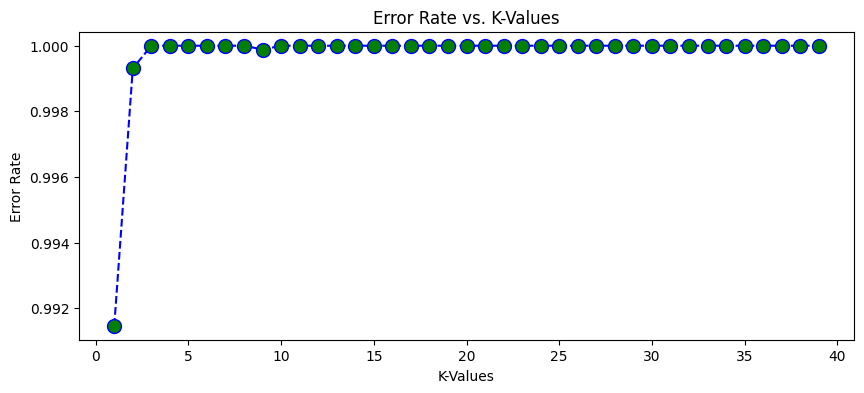

In [40]:
knnRegTest(X_train_creat, X_test_creat, y_train_creat, y_test_creat)

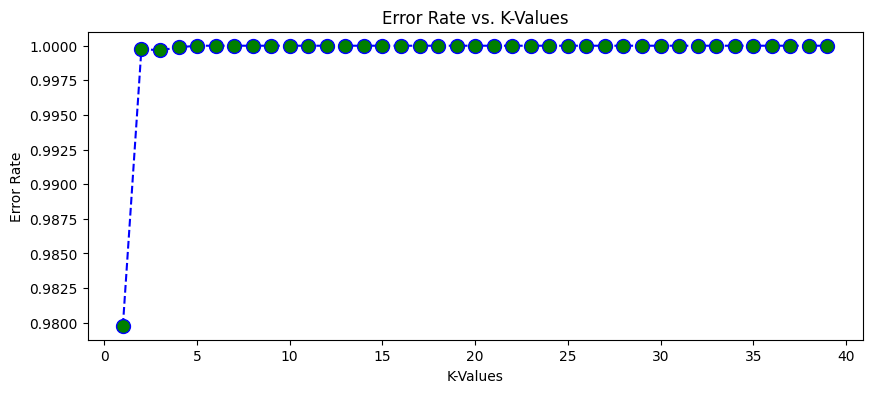

In [41]:
knnRegTest(X_train_nc, X_test_nc, y_train_nc, y_test_nc)

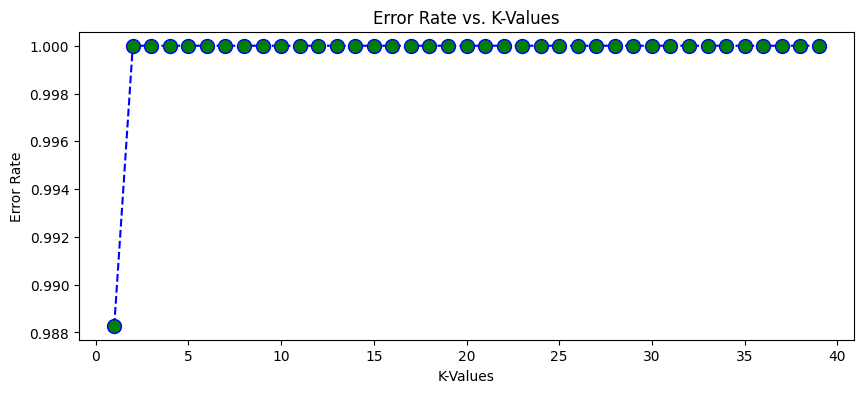

In [42]:
knnRegTest(X_train_pw, X_test_pw, y_train_pw, y_test_pw)

Very concerning results.

In [ ]:
from sklearn.model_selection import GridSearchCV

def gridSearchTest(X_train, y_train):
    grid_params = {'n_neighbors' : [5,7,9,11,13,15],
                'weights' : ['uniform','distance'],
                'metric' : ['minkowski','euclidean','manhattan']}

    # initializing the hyperparameter tuning of KNN

    gs = GridSearchCV(KNeighborsRegressor(), grid_params, verbose = 1, cv=3, n_jobs = -1)

    # fit the model on our train set
    g_res = gs.fit(X_train, y_train)

    # get the hyperparameters with the best score
    print(g_res.best_params_, g_res.best_score_)

In [52]:
gridSearchTest(X_train_creat, y_train_creat)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'} 0.015776105570583066


In [53]:
gridSearchTest(X_train_nc, y_train_nc)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'} 0.07311369978902589


In [54]:
gridSearchTest(X_train_pw, y_train_pw)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
{'metric': 'minkowski', 'n_neighbors': 15, 'weights': 'uniform'} 0.009641495369362133


In [70]:
def knnReg(Xtrain, Xtest, ytrain, ytest, n_neighbors=15, metric='manhattan'):
    # standardize values for wildly different features
    scaler = StandardScaler()
    Xtrain = scaler.fit_transform(Xtrain)
    Xtest = scaler.transform(Xtest)

    knn_regressor = KNeighborsRegressor(n_neighbors=n_neighbors, metric=metric)
    knn_regressor.fit(Xtrain, ytrain)

    y_pred = knn_regressor.predict(Xtest)

    mae = mean_absolute_error(ytest, y_pred)
    mse = mean_squared_error(ytest, y_pred)
    r2 = r2_score(ytest, y_pred)

    print('Mean Absolute Error:', mae, ' ',
          'Mean Squared Error:', mse, ' ',
          'R2 Score:', r2)

    plt.figure(figsize=(10, 6))
    plt.scatter(ytest, y_pred, color='blue', label='Predicted vs Actual')
    plt.plot([min(ytest), max(ytest)], [min(ytest), max(ytest)], color='red', linewidth=2, label='Ideal fit')
    plt.title('KNN Regression: Predicted vs Actual Price (USD)')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.legend()
    plt.show()

    return mae, mse, r2

Mean Absolute Error: 5.107410030162325   Mean Squared Error: 382.49099538370723   R2 Score: 0.08493600775363597


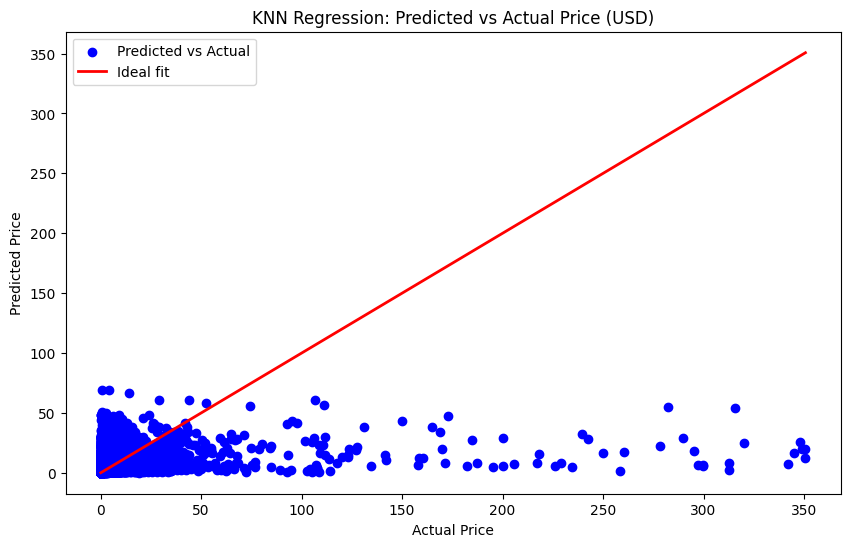

In [76]:
creat_mae, creat_mse, creat_r2 = knnReg(X_train_creat, X_test_creat, y_train_creat, y_test_creat)

In [45]:
# all features
# only reprints: 2.654902617650246, 55.45300337216319, 0.9104151129921156
# no reprints: 1.7066974006585192, 17.211939165958857, 0.8528827198153498
# keep both: 5.134888791632624 399.1699414075267 0.04503362281067269

# commented out certain features (feature importance)
# do not filter reprints: 5.314887973040717 421.9506698038905 -0.009466547191354868

Mean Absolute Error: 9.342630940233617   Mean Squared Error: 2326.126496603383   R2 Score: 0.2401474320500343


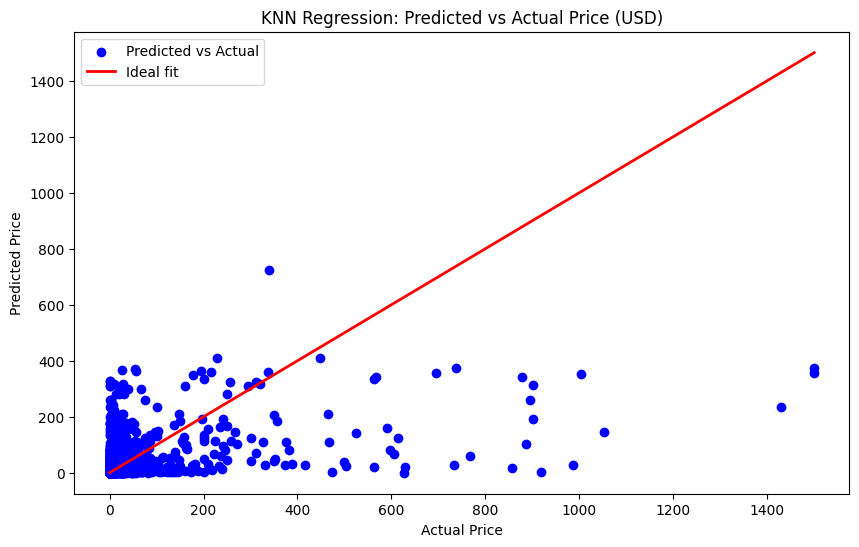

In [72]:
nc_mae, nc_mse, nc_r2 = knnReg(X_train_nc, X_test_nc, y_train_nc, y_test_nc, n_neighbors=5)

In [47]:
# all features
# only reprints: 10.657397388873902, 2340.059543726258, 0.13588161183974057
# no reprints: 8.498510066997621, 2584.2512253227296, -0.03692520884879946
# keep both: 9.79994914599423, 2709.951370818073, 0.11476718435457445

# commented out certain features (feature importance)
# do not filter reprints: 9.261276161074637 2317.8198495657707 0.24286088168048237

Mean Absolute Error: 5.809431819684945   Mean Squared Error: 109.1471050869032   R2 Score: 0.21147483182360438


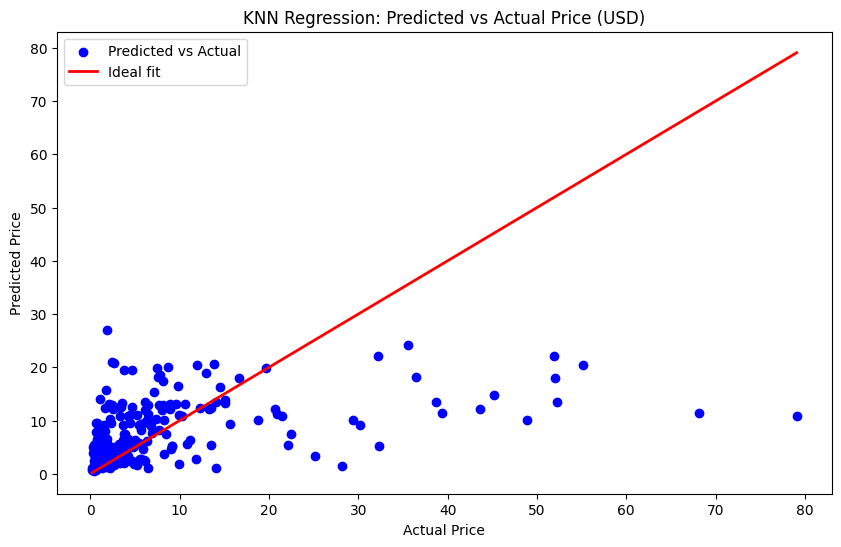

In [ ]:
pw_mae, pw_mse, pw_r2 = knnReg(X_train_pw, X_test_pw, y_train_pw, y_test_pw, n_neighbors=5, metric='minkowski')

In [49]:
# all features
# only reprints: 10.43257975202434, 443.94653226458104, -0.4011172512752892
# no reprints: 5.844670268398271, 188.9456464307137, 0.11663872877770076
# keep both: 6.3048959426857865, 120.76230925444364, 0.12756165050449686

# commented out certain features (feature importance)
# do not filter reprints: 5.7296361004013345 105.35669393793714 0.23885837613580974